# 21. Visualizing Position Encodings

这一节不再只讨论公式，而是直接把主流位置编码方法画出来。

目标不是背定义，而是回答三个更关键的问题：

1. 每一种位置编码到底把什么信息交给了模型？
2. 它是加到输入上，还是加到 attention 分数上，还是直接改写 `Q/K`？
3. 为什么现代 LLM 往往更偏向 RoPE 或它的变体，而不是最早的绝对位置向量？


## Why position is a problem in attention

attention 的核心是 token 两两打分。如果我们只把 token embedding 喂进模型，而不额外告诉模型顺序，那么句子里的 token 集合在数学上更像一个“袋子”，顺序信息会丢掉。

举个最简单的例子：

- `dog bites man`
- `man bites dog`

词几乎一样，但顺序一变，语义完全不同。

所以位置编码的任务，本质上是在补上“这个 token 在哪里”和“它和别的 token 相隔多远”这两类信息。

不同方法的关键差别在于：

- 有些方法编码绝对位置，例如“我在第 37 个位置”。
- 有些方法编码相对位置，例如“我比你早 5 个 token”。
- 有些方法直接改写 token 表示。
- 有些方法不改输入，而是直接改 attention 打分。


## A map of the main families

本节会依次可视化下面这些方法：

1. Learned absolute positional embeddings
2. Sinusoidal positional encodings
3. Rotary positional embeddings, 也就是 RoPE
4. Relative position bias
5. ALiBi
6. RoPE scaling / xPos style intuition
7. 2D positional encoding

你可以先记住一个总对比：

- Learned absolute：灵活，但长度外推差。
- Sinusoidal：固定、无参数、能外推，但和 attention 的相对距离需求并不完全对齐。
- RoPE：直接进入 `Q/K` 的几何关系，因此现代 LLM 很偏爱它。
- Relative bias / ALiBi：直接改 attention 分数，对“远近关系”表达很直接。
- 2D variants：说明位置编码并不只服务于文本。


In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# 让结果可复现。这样每次运行 notebook，图的外观都稳定。
np.random.seed(7)

# 统一保存图片的目录。执行 notebook 时，这些图会额外落盘，方便 README 或文档引用。
OUTPUT_DIR = Path("notebooks/position_encoding_figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11


def save_figure(fig, name):
    """保存图片，避免每个 cell 都重复写保存逻辑。"""
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / name, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## Learned absolute positional embeddings

这是最直接的一类方法。模型维护一张位置表：

- 第 0 个位置有一个向量
- 第 1 个位置有一个向量
- 第 2 个位置有一个向量
- 以此类推

然后把这个位置向量加到 token embedding 上。

它的优点很明显：

- 灵活
- 可学习
- 如果训练数据覆盖充分，模型可以学到很复杂的位置模式

但它也有一个很大的问题：

它学到的是“第 0 位长什么样、第 1 位长什么样”，而不是一种天然可延伸的规则。所以一旦推理长度超过训练时见过的范围，外推通常比较差。

下面这张图不是训练出来的真实参数，而是一个“教学示意版本”。它模仿了可学习参数矩阵的感觉：每个位置有一行向量，每一列是一个维度的参数值。


### Formula and mechanics

最直接的 absolute positional embedding 写法是：

$$
x'_t = x_t + p_t
$$

这里：

- $x_t$ 是第 $t$ 个 token 的内容向量，也就是 token embedding。
- $p_t$ 是第 $t$ 个位置对应的位置向量。
- $x'_t$ 是真正送入后续 Transformer 层的输入。

如果把所有位置向量排成一张表，可以写成：

$$
P \in \mathbb{R}^{L \times d_{model}}
$$

其中：

- $L$ 是最大序列长度。
- $d_{model}$ 是模型隐藏维度。
- 第 $t$ 行 $P_t$ 就是位置 $t$ 的向量。

所以这种方法的本质非常直接：**查表，然后相加**。

它的优势在于表达灵活。模型可以自由学出“第 1 位通常像什么、第 2 位通常像什么、第 100 位通常像什么”。

但问题也正出在这里。因为它学到的是一组离散位置参数，而不是一条可延伸的生成规则，所以一旦推理时长度超出训练范围，模型没有现成的 $p_t$ 可以可靠依赖，或者即使强行扩展，分布也往往不稳定。

换句话说，learned absolute 更像“记住很多具体位置”，而不是“掌握一条位置规律”。


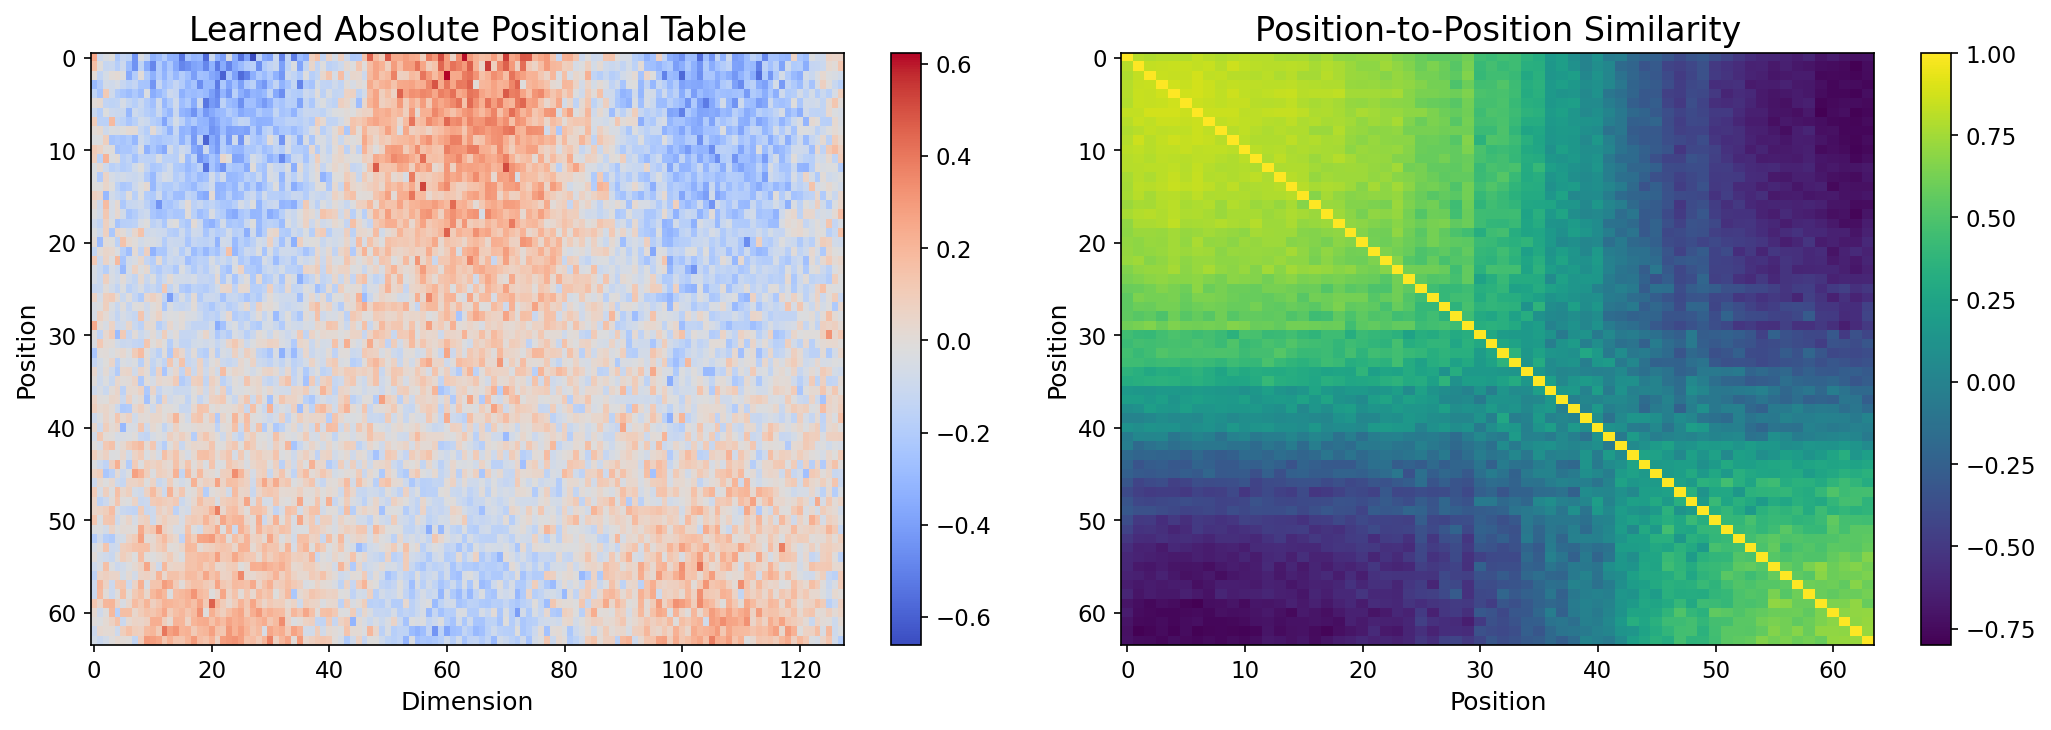

In [2]:
def build_learned_absolute_table(max_len=64, dim=128):
    """构造一个教学用的“可学习位置表”。

    这里不做真正训练，而是用随机初始化后叠加平滑趋势，
    目的是让图既像参数表，又比纯白噪声更容易观察结构。
    """
    table = np.random.normal(0.0, 0.15, size=(max_len, dim))

    # 加一点缓慢变化的趋势，让邻近位置不会完全像噪声。
    row_trend = np.linspace(-1.0, 1.0, max_len)[:, None]
    col_trend = np.sin(np.linspace(0.0, 3.0 * np.pi, dim))[None, :]
    table += 0.35 * row_trend * col_trend

    # 再做一个简单的累计平滑，模拟训练后局部连续性的感觉。
    table = 0.6 * table + 0.4 * np.cumsum(table, axis=0) / (np.arange(max_len)[:, None] + 1)
    return table


learned_table = build_learned_absolute_table()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(learned_table, aspect="auto", cmap="coolwarm")
axes[0].set_title("Learned Absolute Positional Table")
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Position")
fig.colorbar(im0, ax=axes[0])

# 位置相似度图可以帮助看出：这种方法学到的是“每个位置自己的向量”，
# 但它并不会天然保证距离 3 和距离 4 之间存在整洁规律。
similarity = learned_table @ learned_table.T
similarity /= np.linalg.norm(learned_table, axis=1, keepdims=True)
similarity /= np.linalg.norm(learned_table, axis=1, keepdims=True).T

im1 = axes[1].imshow(similarity, aspect="auto", cmap="viridis")
axes[1].set_title("Position-to-Position Similarity")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Position")
fig.colorbar(im1, ax=axes[1])

save_figure(fig, "01_learned_absolute_position.png")


### What to notice

看左图时，重点观察：

- 每一行代表一个位置向量
- 每一列代表一个维度
- 颜色代表该维度上的数值大小

这类图通常不会像正弦编码那样出现非常规则的周期纹理，因为它本来就是由参数学习出来的。

看右图时，重点观察：

- 对角线一定最亮，因为每个位置和自己最相似
- 但离对角线越远，不一定会出现非常平滑、规律的衰减

这就反映出它的本质：它知道“我是第几位”，但它未必把“我们之间差 5”和“我们之间差 6”编码成一种稳定的几何规律。


## Sinusoidal positional encodings

这是 Transformer 最经典的位置编码之一。它不是学习出一个位置表，而是直接用一组不同频率的正弦和余弦来构造每个位置的向量。

直觉上可以把它理解成：

- 低频维度变化慢，负责表达粗粒度位置信息
- 高频维度变化快，负责表达细粒度位置信息

它的主要优点：

- 不需要额外学习参数
- 频率结构很规则
- 理论上可以外推到更长序列

但它的局限也很重要：

它本质上仍然是把某个位置向量加到输入上，而不是专门围绕 attention 里的相对距离关系去设计。


### The original Transformer formula

你问的“最原始那种”，就是 `Attention Is All You Need` 里使用的 sinusoidal positional encoding。原始论文给出的公式是：

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i / d_{model}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i / d_{model}}}\right)
$$

这里每个符号都要看懂：

- $pos$ 表示位置，也就是第几个 token。
- $i$ 表示第几个二维频率对。
- $2i$ 和 $2i+1$ 说明偶数维和奇数维成对出现。
- $d_{model}$ 是隐藏维度总大小。
- $10000^{2i / d_{model}}$ 决定了这一对维度的频率尺度。

这两个公式的设计非常讲究。

第一，为什么偶数维用 `sin`，奇数维用 `cos`？

因为这样每一对维度都可以看作一个二维平面上的相位表示。`sin` 和 `cos` 相差 90 度，相当于给同一个频率提供了两个正交坐标。后面很多关于相位和距离的性质，都是从这个二维配对结构来的。

第二，为什么频率要按指数级变化？

因为模型需要同时看到不同尺度的位置变化：

- 低频维度变化慢，适合表达“我大概在序列前半段还是后半段”。
- 高频维度变化快，适合表达“我和附近位置之间的精细差别”。

第三，为什么它比 learned absolute 更容易外推？

因为它不是靠查一个有限参数表，而是靠一个固定公式生成任意位置的向量。只要给出更大的 $pos$，你就能继续算出对应编码。这并不保证模型一定能完美泛化到超长上下文，但至少位置编码本身不是硬截断在训练长度里的。

第四，它的局限是什么？

它虽然能表达位置，却仍然主要是“把位置向量加到输入上”。这意味着位置信息并不是直接围绕 attention 分数结构设计的。也正因为如此，后来的工作才会进一步发展到 relative bias、RoPE 这一类更贴近 attention 机制本身的方法。


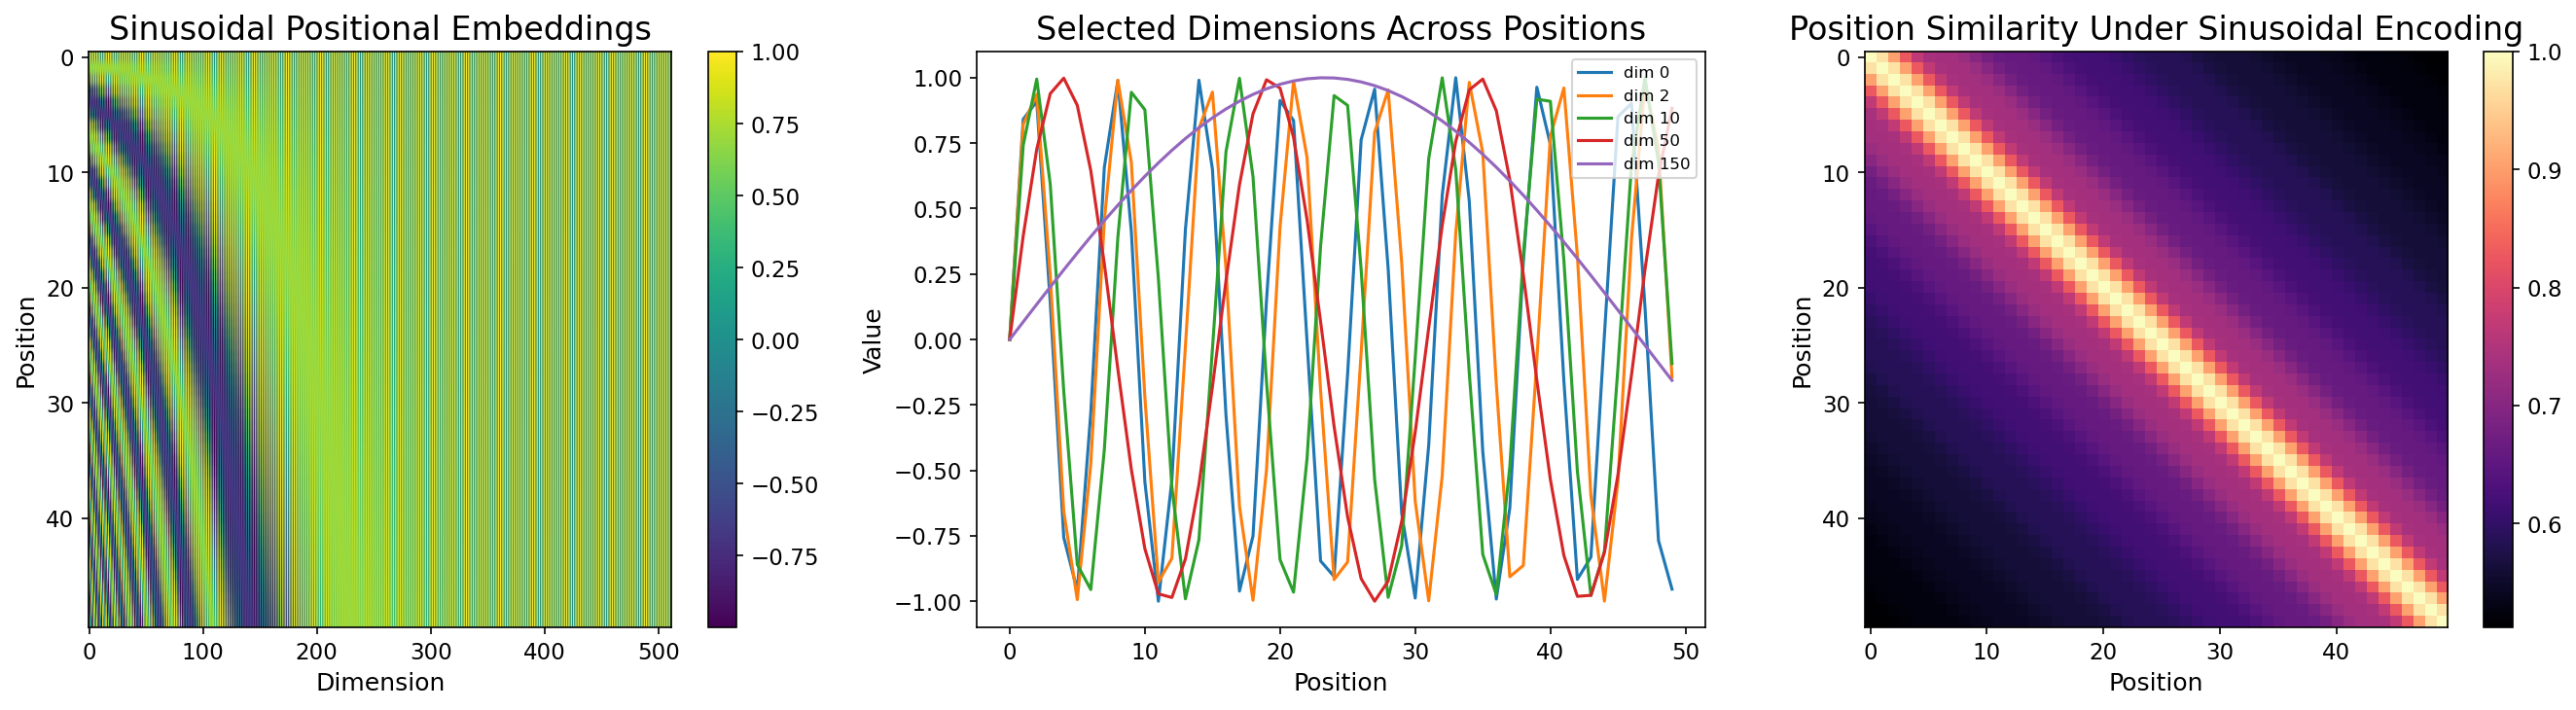

In [3]:
def sinusoidal_encoding(max_len=64, dim=512):
    """构造标准 sinusoidal positional encoding。

    偶数维用 sin，奇数维用 cos。
    频率随着维度升高而指数级变化，这样不同维度能覆盖不同时间尺度。
    """
    positions = np.arange(max_len)[:, None]
    dims = np.arange(0, dim, 2)
    angle_rates = np.exp(-np.log(10000.0) * dims / dim)
    angles = positions * angle_rates[None, :]

    encoding = np.zeros((max_len, dim))
    encoding[:, 0::2] = np.sin(angles)
    encoding[:, 1::2] = np.cos(angles)
    return encoding


sinusoidal_table = sinusoidal_encoding(max_len=50, dim=512)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 这张热力图就是你发来的那种典型视觉形态。
im0 = axes[0].imshow(sinusoidal_table, aspect="auto", cmap="viridis")
axes[0].set_title("Sinusoidal Positional Embeddings")
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Position")
fig.colorbar(im0, ax=axes[0])

# 单独抽几条维度曲线，能更直观看见“不同频率”的存在。
positions = np.arange(sinusoidal_table.shape[0])
for dim_idx in [0, 2, 10, 50, 150]:
    axes[1].plot(positions, sinusoidal_table[:, dim_idx], label=f"dim {dim_idx}")
axes[1].set_title("Selected Dimensions Across Positions")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Value")
axes[1].legend(loc="upper right", fontsize=8)

# 看位置相似度，可以观察不同位置向量之间不是完全随机关系，
# 而是由一组固定频率共同决定的规则几何结构。
sin_similarity = sinusoidal_table @ sinusoidal_table.T
sin_similarity /= np.linalg.norm(sinusoidal_table, axis=1, keepdims=True)
sin_similarity /= np.linalg.norm(sinusoidal_table, axis=1, keepdims=True).T
im2 = axes[2].imshow(sin_similarity, aspect="auto", cmap="magma")
axes[2].set_title("Position Similarity Under Sinusoidal Encoding")
axes[2].set_xlabel("Position")
axes[2].set_ylabel("Position")
fig.colorbar(im2, ax=axes[2])

save_figure(fig, "02_sinusoidal_position.png")


### Why the sinusoidal image looks this way

这张图最重要的视觉特征，是左边低维和右边高维的纹理密度不一样。

- 某些维度变化很慢，所以你会看到大块、平滑的颜色过渡。
- 某些维度变化很快，所以会出现更密集的条纹。

这正是“多频率编码”的结果。模型相当于同时拿到了很多不同时间尺度的位置线索。

它和 learned absolute 的最大区别在于：

- learned absolute 是把每个位置当作一条独立可学习记录
- sinusoidal 是用一套固定数学规则生成所有位置

前者更灵活，后者更有规律，也更容易外推。


## Rotary positional embeddings, or RoPE

RoPE 是现代 LLM 中非常核心的一类方法。它和前面两种最大的不同，不在于“用了什么函数”，而在于“它作用在哪里”。

前面的 absolute / sinusoidal 常见做法是：

- 先得到 token embedding
- 再把位置向量加进去

RoPE 则不同。它会在 attention 内部，对 `Q` 和 `K` 做按维度配对的旋转。

这件事的意义非常大：

- attention 的核心打分是 `Q · K`
- RoPE 改的正好就是 `Q` 和 `K`
- 所以位置信息会直接进入打分几何关系

更直白一点说：

RoPE 不是在 embedding 上贴一个位置标签，而是让“不同位置的向量在几何上发生不同角度的旋转”，于是相对距离会自然体现在点积结果里。


### Formula and geometric meaning

RoPE 的关键不是“也用了 `sin/cos`”，而是它把 `sin/cos` 用在了**旋转**上，而不是简单相加。

对某一个二维配对维度 $(2m, 2m+1)$，RoPE 可以写成：

$$
\begin{bmatrix}
q'_{t,2m} \\
q'_{t,2m+1}
\end{bmatrix}
=
\begin{bmatrix}
\cos \theta_{t,m} & -\sin \theta_{t,m} \\
\sin \theta_{t,m} & \cos \theta_{t,m}
\end{bmatrix}
\begin{bmatrix}
q_{t,2m} \\
q_{t,2m+1}
\end{bmatrix}
$$

对 key 也做同样处理：

$$
\begin{bmatrix}
k'_{t,2m} \\
k'_{t,2m+1}
\end{bmatrix}
=
\begin{bmatrix}
\cos \theta_{t,m} & -\sin \theta_{t,m} \\
\sin \theta_{t,m} & \cos \theta_{t,m}
\end{bmatrix}
\begin{bmatrix}
k_{t,2m} \\
k_{t,2m+1}
\end{bmatrix}
$$

其中角度通常写成：

$$
\theta_{t,m} = t \cdot \omega_m
$$

而 $\omega_m$ 会像原始 sinusoidal 一样，随维度对变化而变化。

真正关键的地方在于 attention 分数：

$$
\text{score}(i,j) = {q'_i}^T k'_j
$$

因为 $q_i$ 和 $k_j$ 分别按位置 $i$ 和 $j$ 旋转过，所以这个点积不再只依赖内容向量本身，还会依赖它们之间的相对相位差。直觉上可以理解成：**两个向量旋转角度差越大，它们的对齐方式就越不同，点积也会跟着变化。**

这就是为什么很多人会说，RoPE 让相对位置信息“自然地”进入 attention。它不是显式地加一张相对距离表，而是通过旋转几何，把距离关系内嵌进 `QK^T` 的结果。

这也解释了它和原始 sinusoidal 的根本差别：

- sinusoidal：位置向量主要加到输入表示上。
- RoPE：位置通过旋转直接进入相似度计算。

所以 RoPE 更像是在改 attention 的计算规则，而不是单纯给 token 加标签。


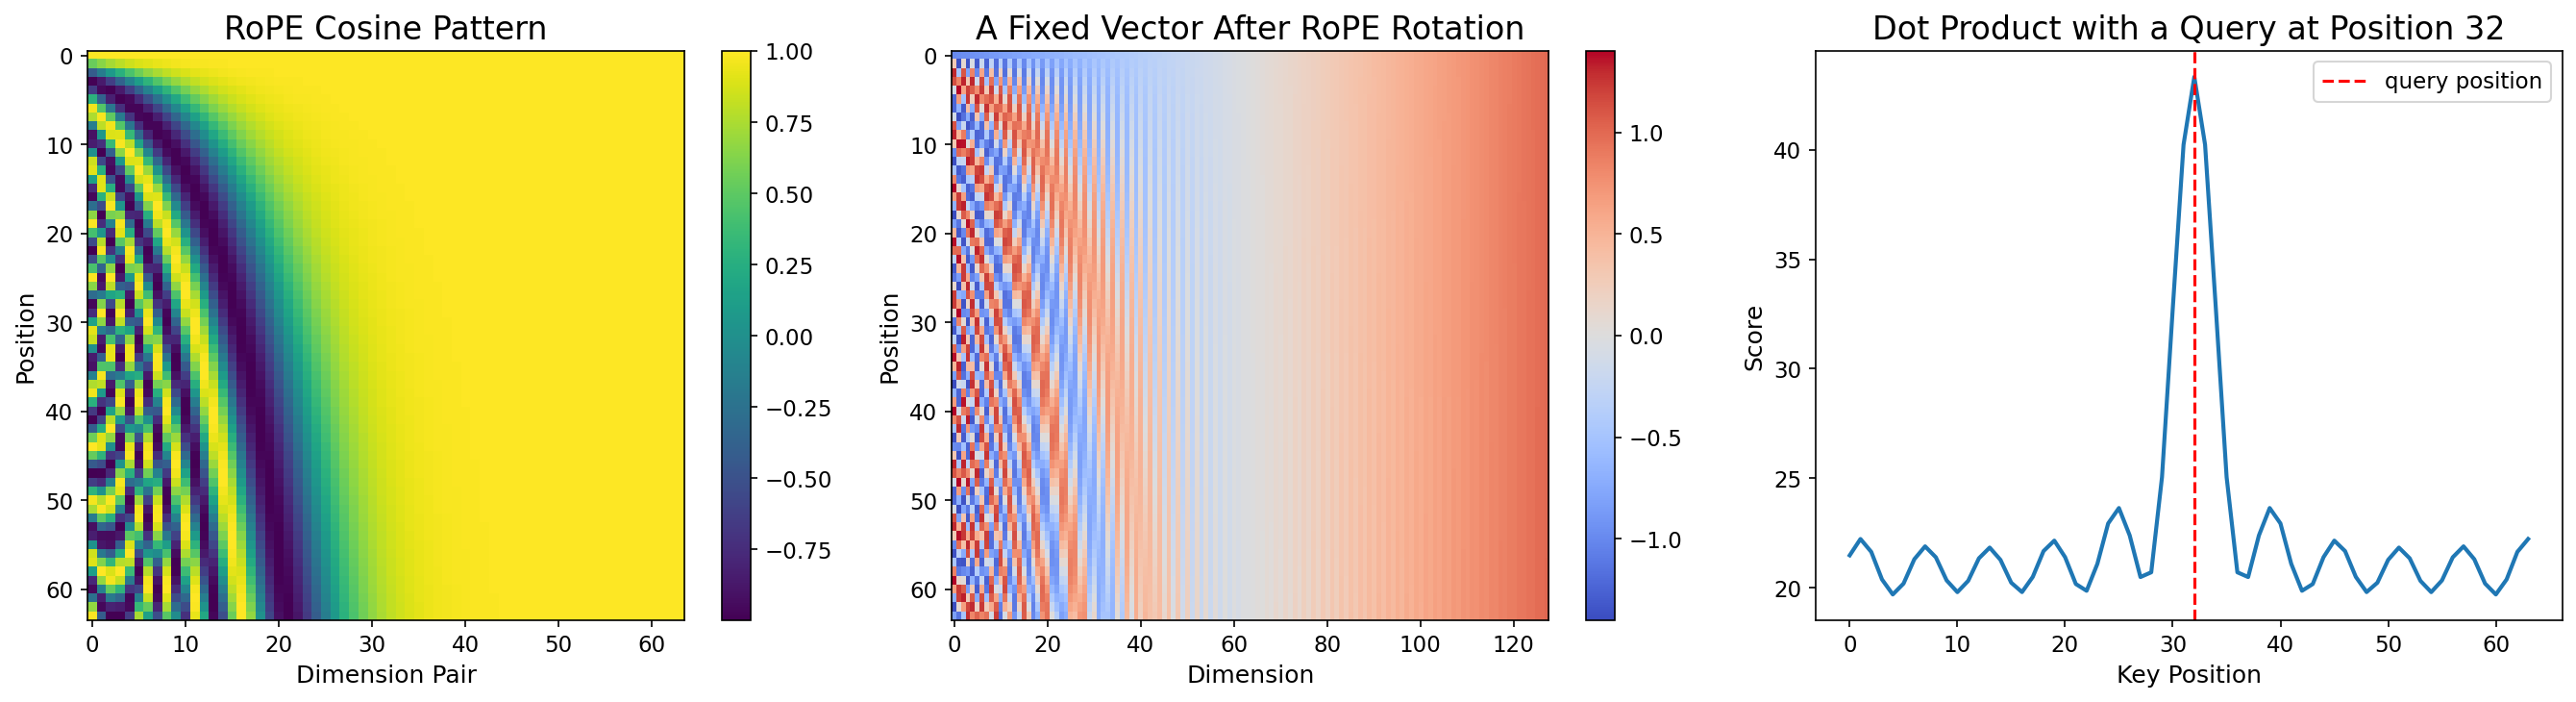

In [4]:
def rope_angles(max_len=64, dim=128, base=10000.0):
    """返回每个位置、每个二维配对通道对应的旋转角度。"""
    positions = np.arange(max_len)[:, None]
    pair_dims = np.arange(0, dim, 2)
    inv_freq = base ** (-pair_dims / dim)
    return positions * inv_freq[None, :]


def apply_rope(x, positions, base=10000.0):
    """对输入向量应用 RoPE。

    输入 x 的 shape: [seq_len, dim]
    dim 必须是偶数，因为每两个维度会组成一个平面，在这个平面内旋转。
    """
    seq_len, dim = x.shape
    assert dim % 2 == 0

    angles = rope_angles(seq_len, dim, base=base)
    cos = np.cos(angles)
    sin = np.sin(angles)

    x_even = x[:, 0::2]
    x_odd = x[:, 1::2]

    rotated_even = x_even * cos - x_odd * sin
    rotated_odd = x_even * sin + x_odd * cos

    out = np.zeros_like(x)
    out[:, 0::2] = rotated_even
    out[:, 1::2] = rotated_odd
    return out


seq_len = 64
dim = 128

# 用一个固定基础向量复制成序列，再只让位置引起差异。
# 这样我们观察到的变化就几乎全部来自 RoPE 自身，而不是 token 内容变化。
base_vector = np.tile(np.linspace(-1.0, 1.0, dim), (seq_len, 1))
rope_table = apply_rope(base_vector, np.arange(seq_len), base=10000.0)
angle_table = rope_angles(seq_len, dim)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(np.cos(angle_table), aspect="auto", cmap="viridis")
axes[0].set_title("RoPE Cosine Pattern")
axes[0].set_xlabel("Dimension Pair")
axes[0].set_ylabel("Position")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(rope_table, aspect="auto", cmap="coolwarm")
axes[1].set_title("A Fixed Vector After RoPE Rotation")
axes[1].set_xlabel("Dimension")
axes[1].set_ylabel("Position")
fig.colorbar(im1, ax=axes[1])

# 观察一个固定 query 与不同位置 key 的点积，会看到 RoPE 让“距离关系”自然进入打分。
query = rope_table[32]
scores = rope_table @ query
axes[2].plot(np.arange(seq_len), scores, linewidth=2)
axes[2].axvline(32, color="red", linestyle="--", label="query position")
axes[2].set_title("Dot Product with a Query at Position 32")
axes[2].set_xlabel("Key Position")
axes[2].set_ylabel("Score")
axes[2].legend()

save_figure(fig, "03_rope_position.png")


### Why RoPE is different from sinusoidal

很多人第一次看到 RoPE 时，会误以为它只是“把 sin/cos 换了个写法”。这不对。

真正的差别在于：

- sinusoidal 常见做法是把位置向量加到输入 embedding 上
- RoPE 是在 attention 内部，直接旋转 `Q/K`

这意味着：

- sinusoidal 更像在输入层附加位置信息
- RoPE 更像在相似度计算规则里植入位置信息

所以现代 decoder-only LLM 更偏爱 RoPE，不是因为它“长得更漂亮”，而是因为它和 attention 的工作方式贴得更紧。


## Relative position bias

还有一大类思路，并不试图把位置混进 token 表示里，而是直接在 attention 分数上做文章。

最简单的表达方式就是：

- 如果两个位置离得近，给它一个偏置
- 如果两个位置离得远，给它另一个偏置

这样 attention 在做 softmax 前，就已经带上了“距离倾向”。

这类方法的优点是直观：它直接服务于“谁该更关注谁”的问题。

它和 absolute / sinusoidal / RoPE 的差别很大：

- 前三者主要是在改 token 表示或 `Q/K`
- relative bias 直接改 score 矩阵


### Formula and interpretation

relative position bias 的最常见写法可以概括为：

$$
\text{score}_{ij} = q_i^T k_j + b_{i-j}
$$

这里：

- $q_i$ 是第 $i$ 个 query。
- $k_j$ 是第 $j$ 个 key。
- $q_i^T k_j$ 是原始内容相似度分数。
- $b_{i-j}$ 是一个只和相对距离 $(i-j)$ 有关的偏置项。

如果 $i$ 和 $j$ 很近，那么 $b_{i-j}$ 可能更大。
如果 $i$ 和 $j$ 很远，那么 $b_{i-j}$ 可能更小，甚至是负值惩罚。

这类方法最重要的思想是：**不去改 token 表示本身，而是直接改“谁看谁”这件事的打分规则。**

它和 absolute encoding 的差别非常本质：

- absolute encoding 问的是“我在第几位”。
- relative bias 问的是“我离你多远”。

在语言建模里，后一个问题往往更贴近注意力真正需要的信息。因为很多语义关系不是由绝对编号决定的，而是由相对距离和相对顺序决定的。


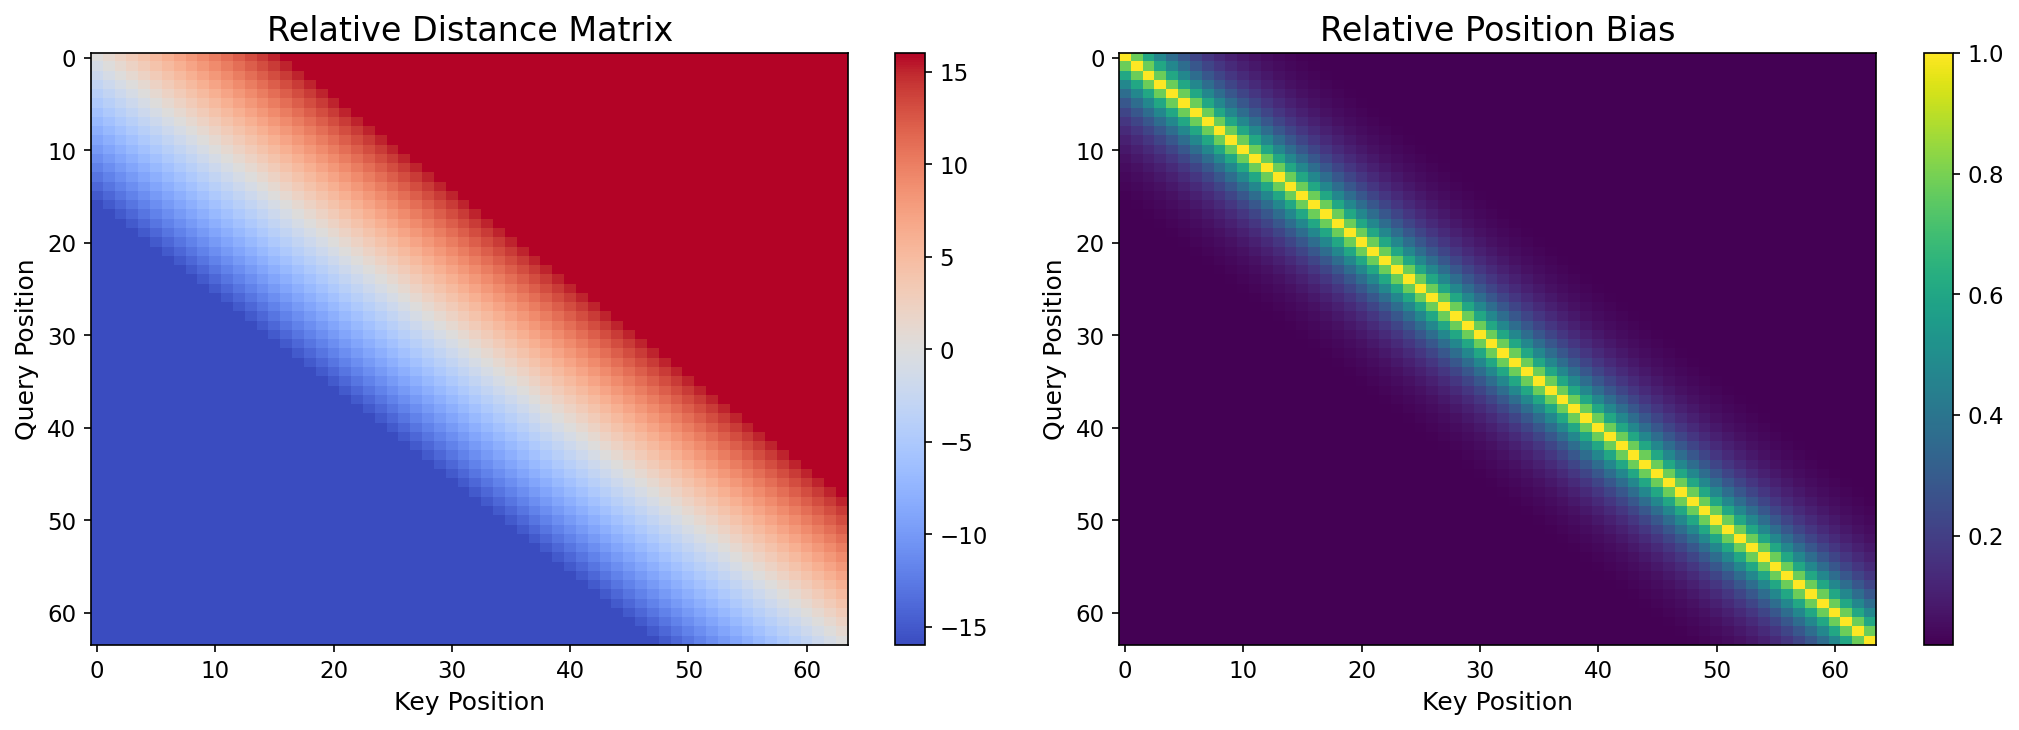

In [5]:
def build_relative_bias_matrix(seq_len=64, clip_distance=16):
    """构造一个教学版相对位置偏置矩阵。

    假设距离越近越容易互相注意，距离越远偏置越低。
    为了避免过远距离无限扩散，这里做一个简单的裁剪。
    """
    q_pos = np.arange(seq_len)[:, None]
    k_pos = np.arange(seq_len)[None, :]
    rel = k_pos - q_pos
    rel = np.clip(rel, -clip_distance, clip_distance)

    # 这里用一个平滑函数模拟“相距越远，偏置越弱”。
    bias = np.exp(-np.abs(rel) / 4.0)
    return rel, bias


rel_distances, rel_bias = build_relative_bias_matrix()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(rel_distances, aspect="auto", cmap="coolwarm")
axes[0].set_title("Relative Distance Matrix")
axes[0].set_xlabel("Key Position")
axes[0].set_ylabel("Query Position")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(rel_bias, aspect="auto", cmap="viridis")
axes[1].set_title("Relative Position Bias")
axes[1].set_xlabel("Key Position")
axes[1].set_ylabel("Query Position")
fig.colorbar(im1, ax=axes[1])

save_figure(fig, "04_relative_position_bias.png")


### What this picture means

这两张图一起看会非常直观。

左图表达的是“距离关系本身”：

- 主对角线是距离 0
- 往右上或左下走，距离逐渐变大

右图表达的是“模型如何利用这种距离”：

- 越靠近对角线，颜色越亮，说明模型更偏向近距离注意力
- 越远离对角线，偏置越小

这和 absolute 方法最大的不同是：

它不需要先问“我在第几位”，而是直接问“我离你多远”。


## ALiBi

ALiBi 可以看作 relative bias 家族里一个非常工程化、也非常简洁的成员。

它的思路很直接：

- attention 分数里直接加入一个和距离成线性关系的惩罚
- 而且不同 head 使用不同的斜率

这意味着：

- 有的 head 更偏爱近距离关系
- 有的 head 对远距离更宽容

它的优点是实现简单、额外成本小、外推能力通常不错。

它和 RoPE 的关键差别在于：

- RoPE 改的是 `Q/K` 的几何关系
- ALiBi 直接改的是分数矩阵


### Formula and head-specific slopes

ALiBi 可以写成一个更具体的 attention 分数形式：

$$
\text{score}^{(h)}_{ij} = q_i^{(h)T} k_j^{(h)} - m_h \cdot d(i,j)
$$

这里：

- $h$ 表示第 $h$ 个 attention head。
- $m_h$ 是这个 head 专属的斜率。
- $d(i,j)$ 是 query 位置和 key 位置之间的距离，常见地会只对过去 token 的距离生效。

它和普通 relative bias 的关系可以理解成：ALiBi 是其中一种极简、结构化的 relative bias。它不再为每个距离学习一个独立参数，而是直接使用“距离乘斜率”这种线性形式。

为什么不同 head 要有不同斜率？

因为这相当于给不同 head 分配不同的距离偏好：

- 斜率大的 head，会更强烈地惩罚远距离，更关注局部上下文。
- 斜率小的 head，对远距离更宽容，更容易保留长程关系。

这样一来，多个 head 可以自动形成多尺度分工。这个思路很朴素，但非常有效，也解释了为什么 ALiBi 虽然简单，却在长上下文场景里经常被拿来比较。


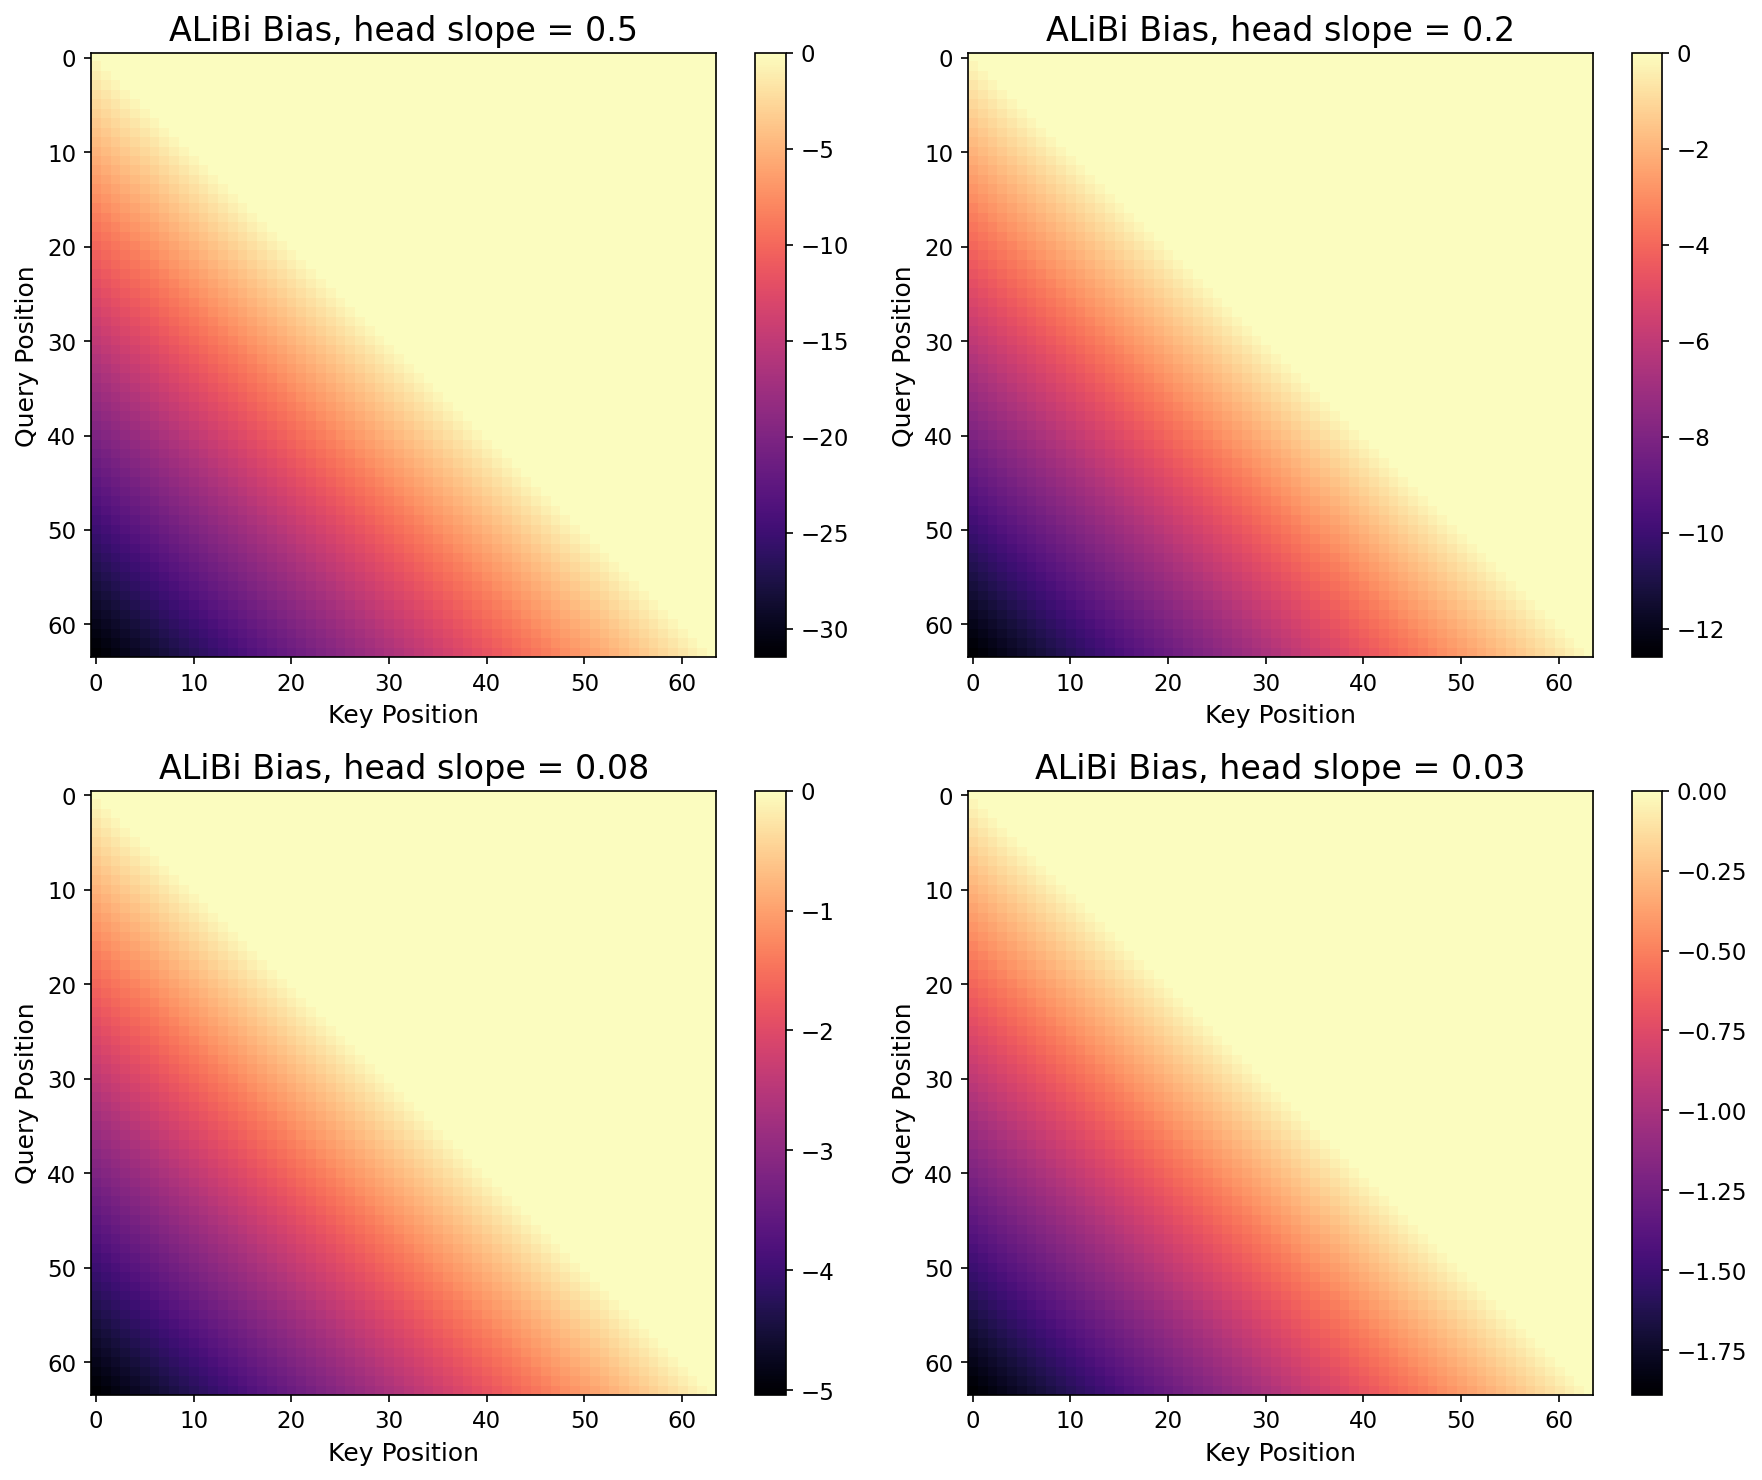

In [6]:
def build_alibi_bias(seq_len=64, slopes=(0.5, 0.2, 0.08, 0.03)):
    """构造多个 head 的 ALiBi 偏置矩阵。"""
    q = np.arange(seq_len)[:, None]
    k = np.arange(seq_len)[None, :]
    distance = np.maximum(q - k, 0)

    biases = []
    for slope in slopes:
        biases.append(-slope * distance)
    return np.array(biases)


alibi_bias = build_alibi_bias()
slopes = [0.5, 0.2, 0.08, 0.03]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, ax in enumerate(axes):
    im = ax.imshow(alibi_bias[i], aspect="auto", cmap="magma")
    ax.set_title(f"ALiBi Bias, head slope = {slopes[i]}")
    ax.set_xlabel("Key Position")
    ax.set_ylabel("Query Position")
    fig.colorbar(im, ax=ax)

save_figure(fig, "05_alibi_position.png")


### How to read the ALiBi plots

这些图的颜色越暗，说明对远距离的惩罚越强。

当 slope 较大时：

- 模型会更强烈地偏好近距离上下文
- 远距离 token 更难拿到高 attention 分数

当 slope 较小时：

- head 对远距离更宽容
- 更容易保留跨长距离的联系

这说明 ALiBi 的表达方式非常直接。它不试图把位置变成一个复杂向量，而是明确告诉每个 head：距离远了，你就该更谨慎。


## RoPE scaling and xPos style intuition

当上下文长度继续拉长时，基础 RoPE 也会遇到挑战。一个常见问题是：随着位置越来越远，相位变化会继续累积，长距离上的几何关系可能变得不够稳定。

于是后面出现了一些扩展思路，例如：

- 通过调整频率分布来做 RoPE scaling
- 通过额外缩放让长距离更稳定，例如 xPos 风格思路

这一类方法的本质，不是推翻 RoPE，而是尽量保留它的优点，同时改善超长上下文外推。


### What scaling is trying to fix

基础 RoPE 的位置角度一般写成：

$$
\theta_{t,m} = t \cdot \omega_m
$$

当 $t$ 很大时，角度会继续增长。对于长上下文来说，这件事可能带来两个问题：

1. 相位变化累积太快，远距离位置之间的几何关系变得更难稳定利用。
2. 模型在训练长度以内学到的模式，未必能平滑地迁移到更长位置区间。

所以很多 RoPE scaling 方法本质上是在修改这个角度增长规律，例如把它变成：

$$
\theta'_{t,m} = \frac{t}{s} \cdot \omega_m
$$

其中 $s$ 是某种缩放系数。缩放后，角度随位置增长得更慢，于是超长范围上的相位变化也更平缓。

xPos 一类思路则会进一步考虑：不仅要让相位增长更稳，还要尽量让长距离上的幅度和相对关系保持得更合理。

所以这一类方法要解决的不是“RoPE 错了”，而是“RoPE 在超长上下文下怎样延伸得更稳”。


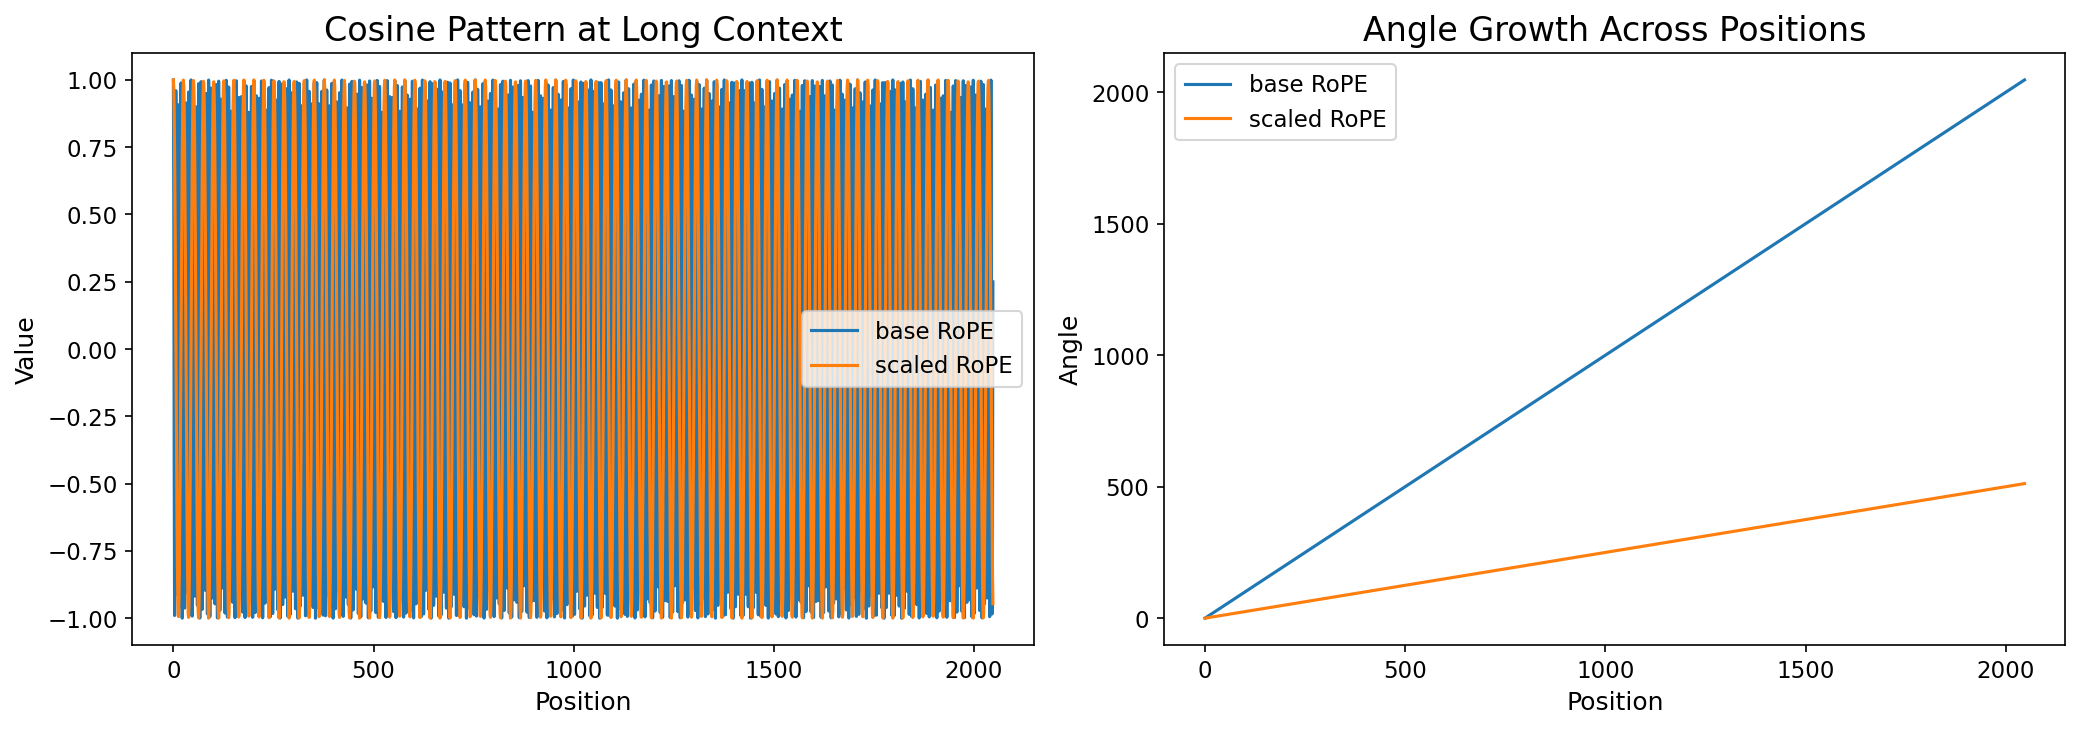

In [7]:
def rope_angle_curve(max_len=2048, dim_index=0, dim=128, base=10000.0, scale=1.0):
    """观察某一个维度对在长上下文下的旋转角增长速度。"""
    positions = np.arange(max_len)
    inv_freq = base ** (-(2 * dim_index) / dim)
    return positions * inv_freq / scale


positions = np.arange(2048)
angle_base = rope_angle_curve(max_len=2048, dim_index=0, dim=128, scale=1.0)
angle_scaled = rope_angle_curve(max_len=2048, dim_index=0, dim=128, scale=4.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(positions, np.cos(angle_base), label="base RoPE")
axes[0].plot(positions, np.cos(angle_scaled), label="scaled RoPE")
axes[0].set_title("Cosine Pattern at Long Context")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(positions, angle_base, label="base RoPE")
axes[1].plot(positions, angle_scaled, label="scaled RoPE")
axes[1].set_title("Angle Growth Across Positions")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Angle")
axes[1].legend()

save_figure(fig, "06_rope_scaling_position.png")


### Why scaling matters

右图非常关键。

- 如果角度增长太快，那么远距离位置之间的相位会变化得非常剧烈。
- 如果做了 scaling，角度增长会更慢，长距离上的变化也更温和。

这并不自动意味着“scaled 一定更好”，但它解释了为什么长上下文模型经常会在基础 RoPE 上继续做工程改造。


## 2D positional encoding

虽然本项目主线是文本模型，但把 2D 位置编码也看一眼很有价值，因为它能帮助你建立更 general 的直觉：位置编码本质上是在给模型补“坐标系”。

在图像或 patch-based 模型里，位置不再只是 1D 序列，而是：

- 第几行
- 第几列

一个常见做法是分别给行和列编码，然后再组合起来。


### Formula for combining row and column signals

当位置不再是一条 1D 序列，而是一个二维网格时，一个自然写法是分别编码行和列，然后再把它们组合起来。

如果第 $(r,c)$ 个网格位置的编码记作 $p_{r,c}$，一种常见形式是：

$$
p_{r,c} = [p^{row}_r ; p^{col}_c]
$$

这里：

- $p^{row}_r$ 表示第 $r$ 行的编码。
- $p^{col}_c$ 表示第 $c$ 列的编码。
- $[a ; b]$ 表示把两个向量拼接起来。

也有人会用相加而不是拼接：

$$
p_{r,c} = p^{row}_r + p^{col}_c
$$

这取决于模型结构和实现选择。

2D 版本最重要的意义，不是某个具体公式，而是让你意识到：位置编码本质上是在给模型补一个坐标系。文本是 1D 坐标，图像 patch 是 2D 坐标，视频甚至可以进一步扩展到时间维。


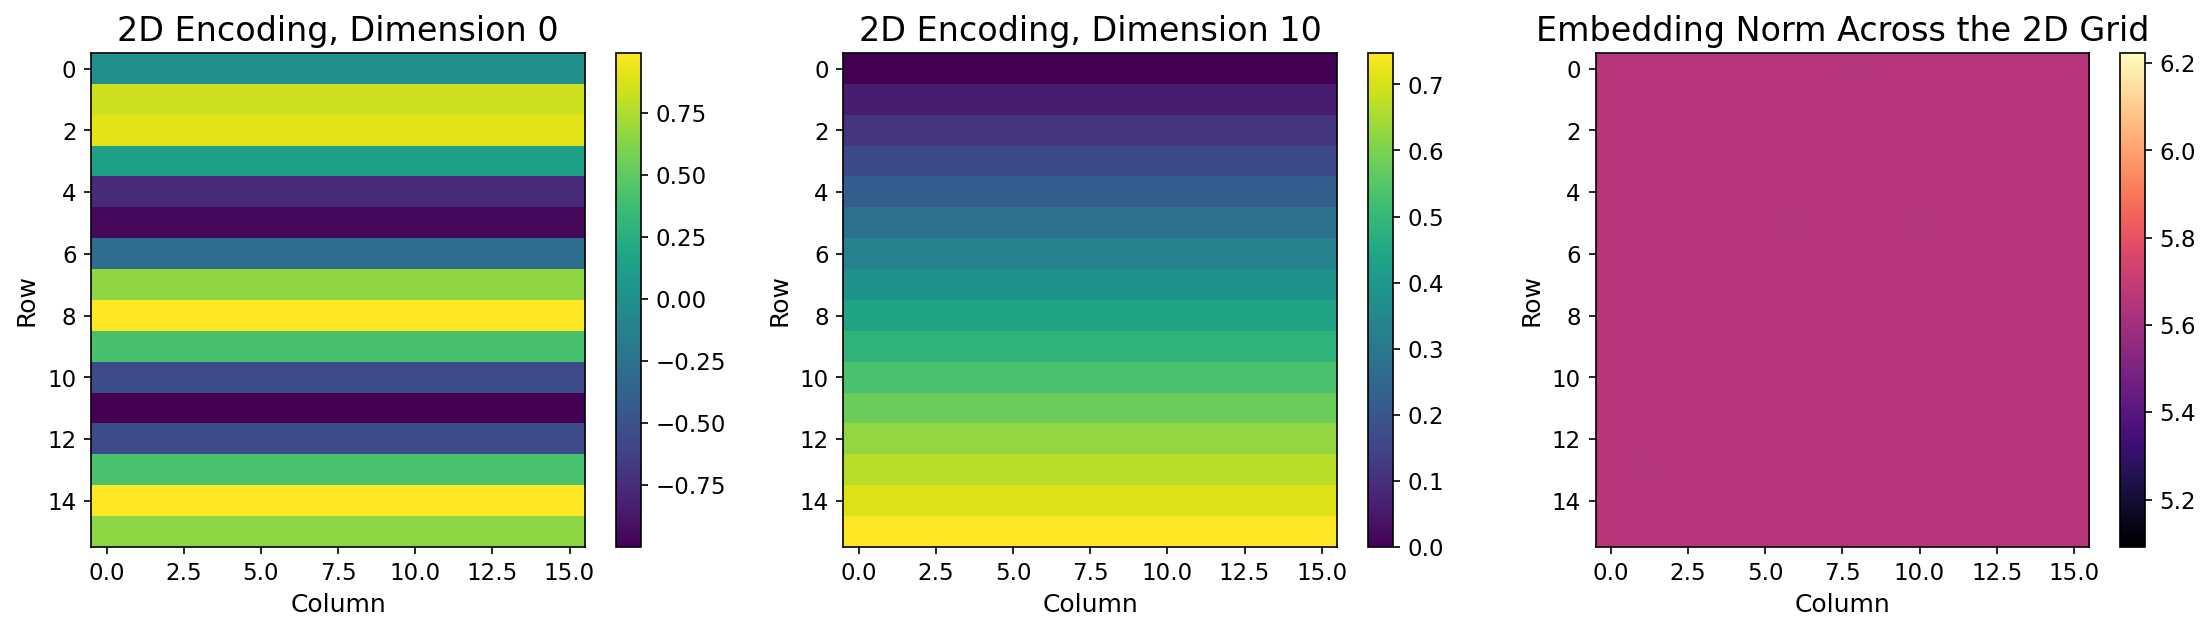

In [8]:
def sinusoidal_1d(max_len, dim):
    return sinusoidal_encoding(max_len=max_len, dim=dim)


rows, cols = 16, 16
dim = 64
row_table = sinusoidal_1d(rows, dim // 2)
col_table = sinusoidal_1d(cols, dim // 2)

# 把每个网格位置的行编码和列编码拼接起来。
grid = np.zeros((rows, cols, dim))
for r in range(rows):
    for c in range(cols):
        grid[r, c] = np.concatenate([row_table[r], col_table[c]])

# 为了可视化二维结构，我们挑一个维度切片来观察整张网格。
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(grid[:, :, 0], cmap="viridis")
axes[0].set_title("2D Encoding, Dimension 0")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(grid[:, :, 10], cmap="viridis")
axes[1].set_title("2D Encoding, Dimension 10")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.linalg.norm(grid, axis=-1), cmap="magma")
axes[2].set_title("Embedding Norm Across the 2D Grid")
axes[2].set_xlabel("Column")
axes[2].set_ylabel("Row")
fig.colorbar(im2, ax=axes[2])

save_figure(fig, "07_2d_position.png")


## Final comparison

| Method | Where it acts | Absolute or relative | Learnable | Long-context extrapolation | Main strength | Main weakness |
| --- | --- | --- | --- | --- | --- | --- |
| Learned absolute | Added to input embeddings | Absolute | Yes | Usually weak | Flexible and expressive | Hard to extrapolate beyond trained length |
| Sinusoidal | Added to input embeddings | Mostly absolute | No | Better than learned absolute | Clean frequency structure, no parameters | Not designed around attention score geometry |
| RoPE | Applied to `Q/K` inside attention | Relative effect emerges through rotation | No | Strong in practice | Position enters attention geometry directly | Harder to understand and tune |
| Relative bias | Added to attention scores | Relative | Often yes | Often decent | Very direct modeling of distance | Does not enrich token representation itself |
| ALiBi | Added to attention scores | Relative | No | Often strong | Cheap, simple, extrapolation-friendly | Less expressive than richer geometric methods |
| RoPE scaling / xPos style | Applied to `Q/K`, but with long-context adjustments | Relative effect | Usually no or minimal | Better at very long context | Preserves RoPE intuition while stretching context | More engineering complexity |
| 2D encodings | Added to inputs or patches | Absolute or mixed | Can be either | Depends on design | Extends the same idea to images or grids | Less directly relevant to 1D text decoding |

最值得记住的主线是：

- absolute methods 更像“给 token 贴位置标签”
- relative methods 更像“直接告诉 attention 谁离谁更近”
- RoPE 则处在一个非常强的位置：它没有简单地贴标签，而是把位置信息直接植入 `Q/K` 的几何关系里

这也是为什么在现代 LLM 里，RoPE 家族会如此常见。


## Takeaway

如果你把这一节真正看懂，应该能回答下面这些问题：

1. 为什么 learned absolute 不容易做长度外推？
2. 为什么 sinusoidal 的图会出现不同密度的条纹？
3. 为什么 RoPE 不是简单的“另一种 sinusoidal”？
4. 为什么 ALiBi 更像是在改“打分规则”，而不是改“token 表示”？
5. 为什么现代长上下文模型还会继续在基础 RoPE 上做 scaling？

如果这些问题你都能自己说清楚，那么你对位置编码的理解就已经不只是“记住名词”，而是真正进入了结构层。
